<a href="https://colab.research.google.com/github/AD-sudo-world/cognitive-gap-reviews/blob/main/cognitive-gap-review-code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
!pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestRegressor

In [2]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.class_weight import compute_class_weight

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df = pd.read_csv('/content/drive/MyDrive/nyka_top_brands_cosmetics_product_reviews.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61284 entries, 0 to 61283
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            61284 non-null  int64  
 1   brand_name            61284 non-null  object 
 2   review_id             61284 non-null  int64  
 3   review_title          61284 non-null  object 
 4   review_text           61275 non-null  object 
 5   author                61284 non-null  object 
 6   review_date           61284 non-null  object 
 7   review_rating         61283 non-null  float64
 8   is_a_buyer            61284 non-null  bool   
 9   pro_user              61284 non-null  bool   
 10  review_label          48249 non-null  object 
 11  product_title         61284 non-null  object 
 12  mrp                   61284 non-null  int64  
 13  price                 61284 non-null  int64  
 14  product_rating        61284 non-null  float64
 15  product_rating_coun

In [ ]:
df = df[['review_text', 'review_rating']].copy()

In [ ]:
df = df.dropna(subset=['review_text', 'review_rating'])

In [ ]:
print(df['review_rating'].value_counts().sort_index())

review_rating
1.0     3077
2.0     1718
3.0     3540
4.0    11318
5.0    41621
Name: count, dtype: int64


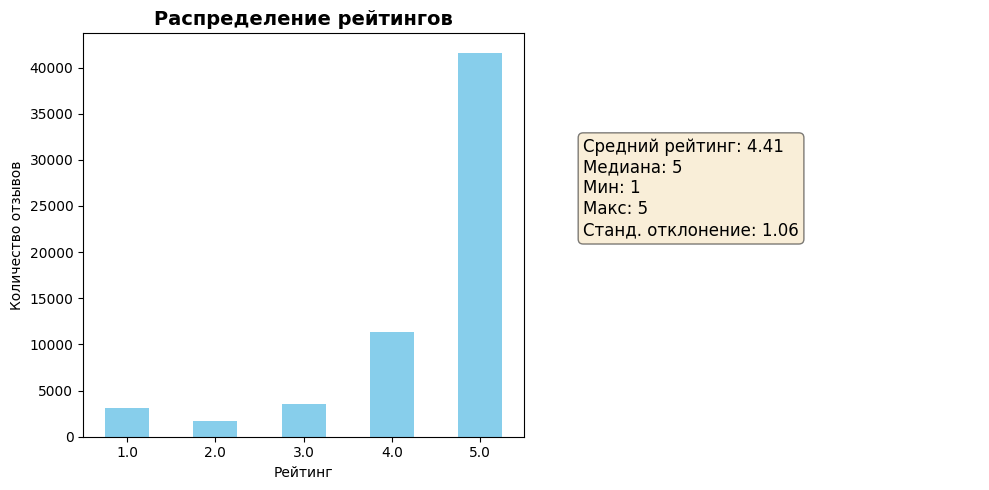

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['review_rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Распределение рейтингов', fontsize=14, fontweight='bold')
plt.xlabel('Рейтинг')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=0)
plt.subplot(1, 2, 2)
stats = df['review_rating'].describe()
plt.text(0.1, 0.5,
         f"Средний рейтинг: {stats['mean']:.2f}\n"
         f"Медиана: {stats['50%']:.0f}\n"
         f"Мин: {stats['min']:.0f}\n"
         f"Макс: {stats['max']:.0f}\n"
         f"Станд. отклонение: {stats['std']:.2f}",
         fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(text):
    try:
        from nltk.corpus import stopwords
        import nltk
        nltk.download('stopwords', quiet=True)
        stop_words = set(stopwords.words('english'))
        words = text.split()
        words = [word for word in words if word not in stop_words]
        return ' '.join(words)
    except:
        return text

In [ ]:
df['text_clean'] = df['review_text'].apply(clean_text)

In [ ]:
df = df[df['text_clean'].str.len() > 10]

In [ ]:
df['text_clean'] = df['text_clean'].apply(remove_stopwords)

In [ ]:
for i in range(3):
    print(f"{i+1}. {df['text_clean'].iloc[i][:100]}...")

1. works claims could see difference first day use olay cleanser best results...
2. claims best thing smoothens ur skin n makes soft liked...
3. using product months perfect combination n oily skin non greasy absorbs quickly moisturises well doe...


Анализ тональности с помощью TextBlob

In [ ]:
def get_sentiment(text):
    try:
        blob = TextBlob(text)
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except:
        return 0.0, 0.0

Извлечение дополнительных признаков

In [ ]:
df['text_length'] = df['text_clean'].str.len()
df['word_count'] = df['text_clean'].str.split().str.len()
df['sentiment_polarity'] = df['review_text'].apply(lambda x: get_sentiment(x)[0])
df['sentiment_subjectivity'] = df['review_text'].apply(lambda x: get_sentiment(x)[1])

Маркеры противоречий

In [ ]:
contradiction_markers = ['but', 'however', 'although', 'though', 'yet', 'except']
df['has_contradiction'] = df['review_text'].str.lower().str.contains('|'.join(contradiction_markers)).astype(int)

Безопасный подсчет вхождений с экранированием

In [ ]:
def safe_count(text, pattern):
    try:
        return str(text).count(pattern)
    except:
        return 0

Эмоциональные маркеры

In [ ]:
df['exclamation_count'] = df['review_text'].apply(lambda x: safe_count(x, '!'))
df['question_count'] = df['review_text'].apply(lambda x: safe_count(x, '?'))

Топ-слова в положительных и отрицательных отзывах

In [ ]:
positive_texts = df[df['review_rating'] >= 4]['text_clean'].tolist()
negative_texts = df[df['review_rating'] <= 2]['text_clean'].tolist()

if positive_texts and negative_texts:
    vectorizer = CountVectorizer(max_features=10, stop_words='english')

    # Положительные
    pos_vec = vectorizer.fit_transform(positive_texts)
    pos_words = vectorizer.get_feature_names_out()
    pos_counts = pos_vec.toarray().sum(axis=0)

    # Отрицательные
    neg_vec = vectorizer.fit_transform(negative_texts)
    neg_words = vectorizer.get_feature_names_out()
    neg_counts = neg_vec.toarray().sum(axis=0)

    print("\nТоп-5 слов в положительных отзывах:")
    for word, count in sorted(zip(pos_words, pos_counts), key=lambda x: -x[1])[:5]:
        print(f"  {word}: {count}")

    print("\nТоп-5 слов в отрицательных отзывах:")
    for word, count in sorted(zip(neg_words, neg_counts), key=lambda x: -x[1])[:5]:
        print(f"  {word}: {count}")

print(f"\nВсего признаков: {len(df.columns)}")


Топ-5 слов в положительных отзывах:
  good: 12959
  product: 11053
  skin: 8741
  love: 8671
  shade: 8535

Топ-5 слов в отрицательных отзывах:
  product: 1407
  hair: 1036
  good: 869
  like: 805
  skin: 798

Всего признаков: 10


ГЕНЕРАЦИЯ BERT ЭМБЕДДИНГОВ

In [ ]:
model_name = 'bert-base-nli-mean-tokens'
bert_model = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
texts = df['text_clean'].tolist()

In [ ]:
max_samples = 100000
if len(texts) > max_samples:
    indices = np.random.choice(len(texts), max_samples, replace=False)
    texts = [texts[i] for i in indices]
    df = df.iloc[indices].reset_index(drop=True)
    y = df['review_rating'].values

embeddings = bert_model.encode(
    texts,
    batch_size=64,          # Размер батча для ускорения
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Размер эмбеддингов: {embeddings.shape}")

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Размер эмбеддингов: (50000, 768)


In [ ]:
y = df['review_rating'].values

In [ ]:
indices = np.arange(len(df))

In [ ]:
X_embeddings = embeddings
X_extra = df[['text_length', 'word_count', 'sentiment_polarity',
              'sentiment_subjectivity', 'has_contradiction',
              'exclamation_count', 'question_count']].values

X = np.hstack([X_embeddings, X_extra])

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(f"\nОбучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")


Обучающая выборка: 40000 записей
Тестовая выборка: 10000 записей


In [ ]:
#classes = np.array([1, 2, 3, 4, 5])
#base_weights = compute_class_weight('balanced', classes=classes, y=y_train)

#optimal_weights = {
    #1: base_weights[0] * 1.5,
    #2: base_weights[1] * 1.3,
    #3: base_weights[2] * 1.1,
    #4: base_weights[3] * 0.9,
    #5: base_weights[4] * 0.85
#}

#for rating, weight in optimal_weights.items():
    #count = np.sum(y_train == rating)
    #print(f"  Рейтинг {rating}: вес={weight:.3f}, кол-во={count}")

#sample_weights = np.array([optimal_weights[y] for y in y_train])

 МАСШТАБИРОВАНИЕ

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

In [ ]:
model.fit(
    X_train_scaled,
    y_train,
    #sample_weight=sample_weights,
    verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

ПРЕДСКАЗАНИЕ И ОЦЕНКА

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred_rounded = np.round(y_pred).clip(1, 5)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Метрики качества:")
print(f"  MAE: {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")

Метрики качества:
  MAE: 0.5498
  RMSE: 0.8000
  R²: 0.4389


КОГНИТИВНЫЙ РАЗРЫВ

In [ ]:
gap = y_test - y_pred_rounded
abs_gap = np.abs(gap)

# Классификация силы разрыва
def classify_gap_strength(g):
    if g == 0:
        return 'Нет разрыва'
    elif g == 1:
        return 'Слабый'
    elif g == 2:
        return 'Умеренный'
    else:
        return 'Сильный'

# Классификация направления разрыва
def classify_gap_direction(g):
    if g == 0:
        return 'Совпадение'
    elif g > 0:
        return 'Завышенная оценка'
    else:
        return 'Заниженная оценка'

gap_strength = [classify_gap_strength(g) for g in abs_gap]
gap_direction = [classify_gap_direction(g) for g in gap]

# Создаем датафрейм результатов
df_results = pd.DataFrame({
    'review_text': df.iloc[idx_test]['review_text'].values,
    'text_clean': df.iloc[idx_test]['text_clean'].values,
    'actual_rating': y_test,
    'predicted_rating': y_pred_rounded,
    'predicted_prob': y_pred,
    'gap': gap,
    'abs_gap': abs_gap,
    'gap_direction': gap_direction,
    'gap_strength': gap_strength,
    'text_length': df.iloc[idx_test]['text_length'].values,
    'word_count': df.iloc[idx_test]['word_count'].values,
    'sentiment_polarity': df.iloc[idx_test]['sentiment_polarity'].values,
    'sentiment_subjectivity': df.iloc[idx_test]['sentiment_subjectivity'].values,
    'has_contradiction': df.iloc[idx_test]['has_contradiction'].values,
    'exclamation_count': df.iloc[idx_test]['exclamation_count'].values,
    'question_count': df.iloc[idx_test]['question_count'].values
})

In [ ]:
no_gap = df_results[df_results['abs_gap'] == 0]
weak_gap = df_results[df_results['abs_gap'] == 1]
moderate_gap = df_results[df_results['abs_gap'] == 2]
strong_gap = df_results[df_results['abs_gap'] >= 3]

print(f"Распределение силы когнитивного разрыва:")
print(f"  Нет разрыва: {len(no_gap)} ({len(no_gap)/len(df_results)*100:.1f}%)")
print(f"  Слабый разрыв: {len(weak_gap)} ({len(weak_gap)/len(df_results)*100:.1f}%)")
print(f"  Умеренный разрыв: {len(moderate_gap)} ({len(moderate_gap)/len(df_results)*100:.1f}%)")
print(f"  Сильный разрыв: {len(strong_gap)} ({len(strong_gap)/len(df_results)*100:.1f}%)")

print(f"\nСредний разрыв: {gap.mean():.3f}")
print(f"Максимальный разрыв: {abs_gap.max():.0f}")

Распределение силы когнитивного разрыва:
  Нет разрыва: 6250 (62.5%)
  Слабый разрыв: 3022 (30.2%)
  Умеренный разрыв: 527 (5.3%)
  Сильный разрыв: 201 (2.0%)

Средний разрыв: -0.109
Максимальный разрыв: 4


In [ ]:
strong_gap = df_results[df_results['abs_gap'] >= 2]
moderate_gap = df_results[df_results['abs_gap'] == 1]
no_gap = df_results[df_results['abs_gap'] == 0]

print(f"Количество отзывов с сильным разрывом: {len(strong_gap)}")
print(f"Доля: {len(strong_gap)/len(df_results)*100:.2f}%")
print(f"Количество отзывов с умеренным разрывом: {len(moderate_gap)}")
print(f"Доля: {len(moderate_gap)/len(df_results)*100:.2f}%")
print(f"Количество отзывов без разрыва: {len(no_gap)}")
print(f"Доля: {len(no_gap)/len(df_results)*100:.2f}%")

Количество отзывов с сильным разрывом: 728
Доля: 7.28%
Количество отзывов с умеренным разрывом: 3022
Доля: 30.22%
Количество отзывов без разрыва: 6250
Доля: 62.50%


In [ ]:
print("\n Наличие противоречий в отзывах с сильным разрывом:")
contradiction_stats = strong_gap['has_contradiction'].value_counts(normalize=True) * 100
for val, pct in contradiction_stats.items():
    label = "Есть противоречия" if val == 1 else "Нет противоречий"
    print(f"  {label}: {pct:.1f}%")

print("\nСравнение с отзывами без разрыва:")
no_gap_contradiction = no_gap['has_contradiction'].value_counts(normalize=True) * 100
for val, pct in no_gap_contradiction.items():
    label = "Есть противоречия" if val == 1 else "Нет противоречий"
    print(f"  {label}: {pct:.1f}%")

print("\n Средняя длина текста по направлению разрыва:")
length_by_direction = strong_gap.groupby('gap_direction')['text_length'].mean()
for direction, length in length_by_direction.items():
    print(f"  {direction}: {length:.1f} символов")

print(f"  Отзывы без разрыва: {no_gap['text_length'].mean():.1f} символов")

print("\n Средняя эмоциональность (восклицания) по направлению разрыва:")
exclamation_by_direction = strong_gap.groupby('gap_direction')['exclamation_count'].mean()
for direction, count in exclamation_by_direction.items():
    print(f"  {direction}: {count:.2f} восклицаний")


print(f"  Отзывы без разрыва: {no_gap['exclamation_count'].mean():.2f} восклицаний")


print("\n Средняя полярность сентимента по направлению разрыва:")
polarity_by_direction = strong_gap.groupby('gap_direction')['sentiment_polarity'].mean()
for direction, polarity in polarity_by_direction.items():
    print(f"  {direction}: {polarity:.3f}")

print(f"  Отзывы без разрыва: {no_gap['sentiment_polarity'].mean():.3f}")


 Наличие противоречий в отзывах с сильным разрывом:
  Нет противоречий: 70.7%
  Есть противоречия: 29.3%

Сравнение с отзывами без разрыва:
  Нет противоречий: 86.1%
  Есть противоречия: 13.9%

 Средняя длина текста по направлению разрыва:
  Завышенная оценка: 80.4 символов
  Заниженная оценка: 81.5 символов
  Отзывы без разрыва: 75.0 символов

 Средняя эмоциональность (восклицания) по направлению разрыва:
  Завышенная оценка: 0.17 восклицаний
  Заниженная оценка: 0.12 восклицаний
  Отзывы без разрыва: 0.20 восклицаний

 Средняя полярность сентимента по направлению разрыва:
  Завышенная оценка: -0.023
  Заниженная оценка: 0.183
  Отзывы без разрыва: 0.425


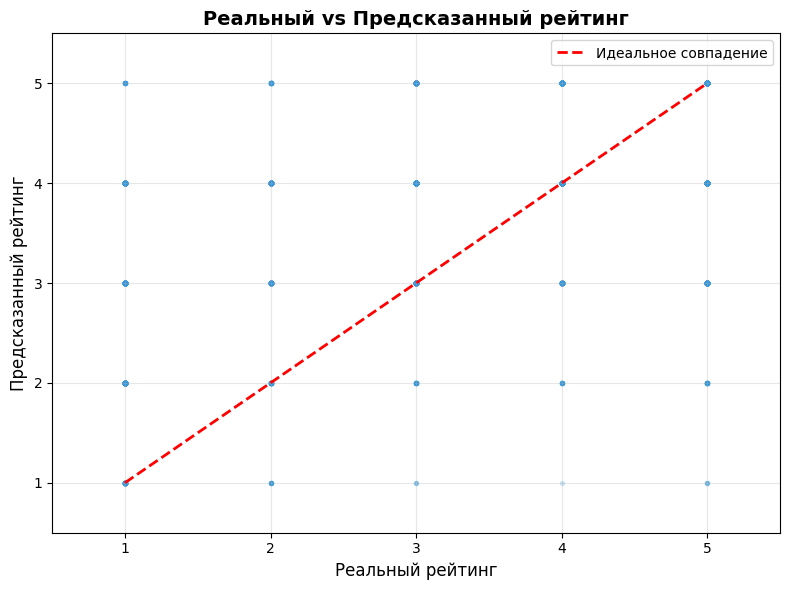

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rounded, alpha=0.2, s=8, c='#3498db')
plt.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Идеальное совпадение')
plt.xlabel('Реальный рейтинг', fontsize=12)
plt.ylabel('Предсказанный рейтинг', fontsize=12)
plt.title('Реальный vs Предсказанный рейтинг', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0.5, 5.5)
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

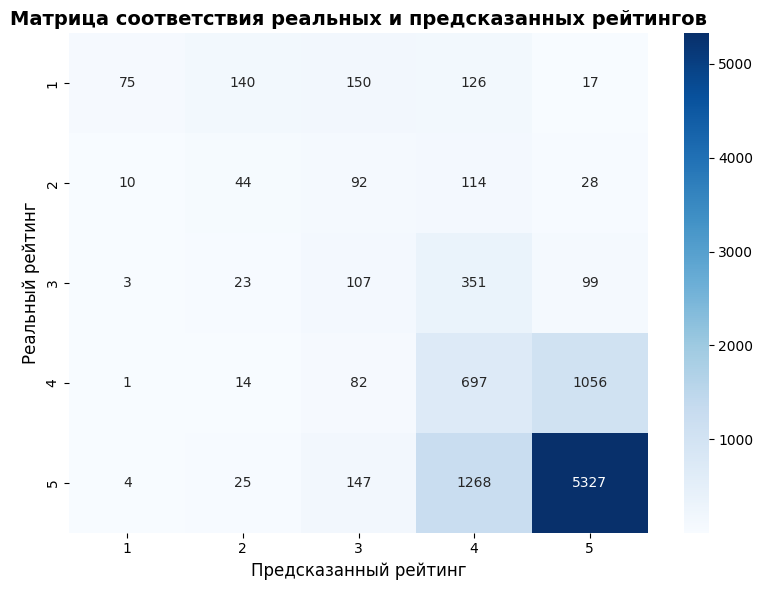

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rounded)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)
plt.title('Матрица соответствия реальных и предсказанных рейтингов', fontsize=14, fontweight='bold')
plt.xlabel('Предсказанный рейтинг', fontsize=12)
plt.ylabel('Реальный рейтинг', fontsize=12)
plt.tight_layout()
plt.show()

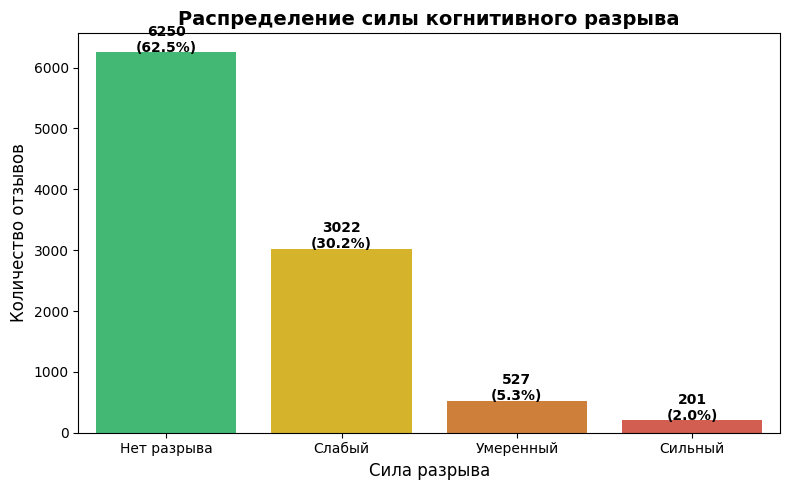

In [ ]:
plt.figure(figsize=(8, 5))
order = ['Нет разрыва', 'Слабый', 'Умеренный', 'Сильный']
colors_gap = {'Нет разрыва': '#2ecc71', 'Слабый': '#f1c40f', 'Умеренный': '#e67e22', 'Сильный': '#e74c3c'}
sns.countplot(
    data=df_results,
    x='gap_strength',
    order=order,
    palette=[colors_gap[cat] for cat in order]
)
plt.title('Распределение силы когнитивного разрыва', fontsize=14, fontweight='bold')
plt.xlabel('Сила разрыва', fontsize=12)
plt.ylabel('Количество отзывов', fontsize=12)
for i, cat in enumerate(order):
    count = len(df_results[df_results['gap_strength'] == cat])
    plt.text(i, count + 10, f'{count}\n({count/len(df_results)*100:.1f}%)',
             ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

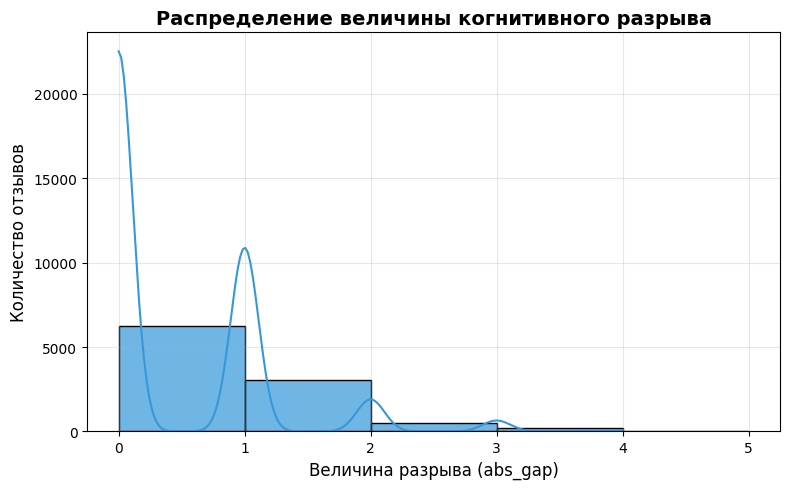

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df_results['abs_gap'],
    bins=range(0, 6),
    kde=True,
    color='#3498db',
    alpha=0.7
)
plt.title('Распределение величины когнитивного разрыва', fontsize=14, fontweight='bold')
plt.xlabel('Величина разрыва (abs_gap)', fontsize=12)
plt.ylabel('Количество отзывов', fontsize=12)
plt.xticks(range(0, 6))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

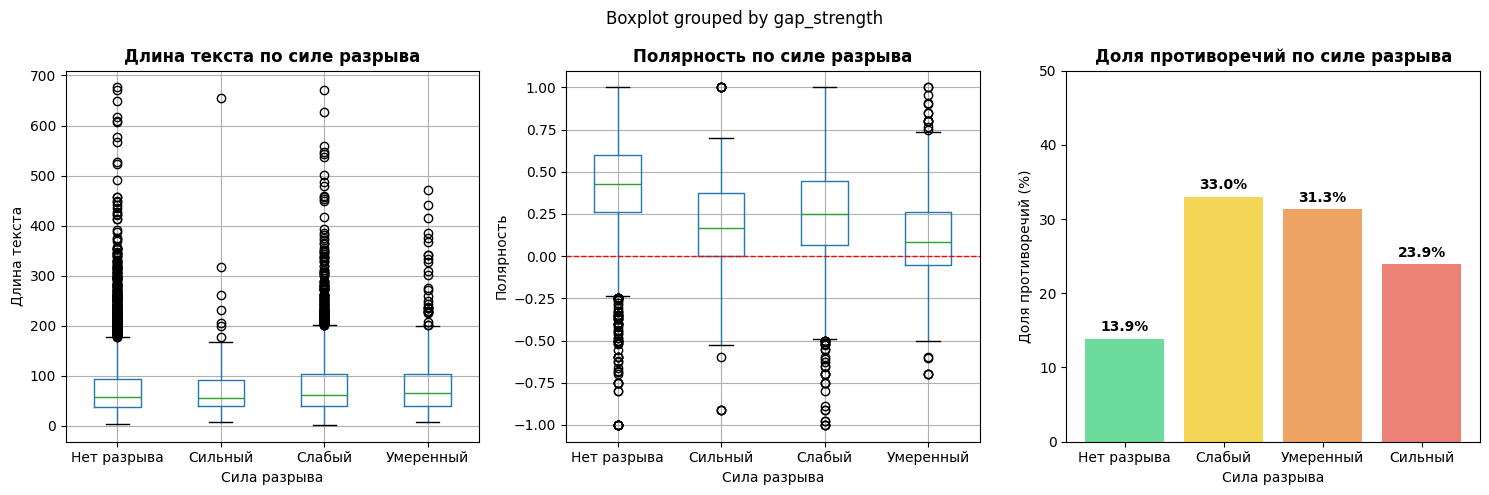

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


ax = axes[0]
df_results.boxplot(column='text_length', by='gap_strength', ax=ax)
ax.set_title('Длина текста по силе разрыва', fontsize=12, fontweight='bold')
ax.set_xlabel('Сила разрыва')
ax.set_ylabel('Длина текста')


ax = axes[1]
df_results.boxplot(column='sentiment_polarity', by='gap_strength', ax=ax)
ax.set_title('Полярность по силе разрыва', fontsize=12, fontweight='bold')
ax.set_xlabel('Сила разрыва')
ax.set_ylabel('Полярность')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)


ax = axes[2]
contradiction_by_strength = df_results.groupby('gap_strength')['has_contradiction'].mean() * 100
contradiction_by_strength = contradiction_by_strength.reindex(order)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(contradiction_by_strength.index, contradiction_by_strength.values, color=colors, alpha=0.7)
ax.set_title('Доля противоречий по силе разрыва', fontsize=12, fontweight='bold')
ax.set_xlabel('Сила разрыва')
ax.set_ylabel('Доля противоречий (%)')
ax.set_ylim(0, 50)
for bar, val in zip(bars, contradiction_by_strength.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



In [ ]:
top_gap = df_results.sort_values(by='abs_gap', ascending=False).head(10)

for i, row in top_gap.iterrows():
    print(f"Отзыв #{i}")
    print(f"Реальный рейтинг: {row['actual_rating']}")
    print(f"Предсказанный рейтинг: {row['predicted_rating']}")
    print(f"Разрыв: {row['gap']}")
    print(f"Направление: {row['gap_direction']}")
    print(f"Сила: {row['gap_strength']}")
    print(f"Длина текста: {row['text_length']} символов")
    print(f"Полярность: {row['sentiment_polarity']:.3f}")
    print(f"Противоречия: {'Есть' if row['has_contradiction'] == 1 else 'Нет'}")
    print(f"Восклицаний: {row['exclamation_count']}")
    print('\nТекст:')
    text = row['review_text']
    print(text[:500] + '...' if len(text) > 500 else text)

Отзыв #8505
Реальный рейтинг: 1.0
Предсказанный рейтинг: 5.0
Разрыв: -4.0
Направление: Заниженная оценка
Сила: Сильный
Длина текста: 31 символов
Полярность: 1.000
Противоречия: Нет
Восклицаний: 0

Текст:
Nykaa u are awesome just cant stop myself from using these
Отзыв #4092
Реальный рейтинг: 1.0
Предсказанный рейтинг: 5.0
Разрыв: -4.0
Направление: Заниженная оценка
Сила: Сильный
Длина текста: 81 символов
Полярность: 0.517
Противоречия: Нет
Восклицаний: 0

Текст:
This setting spray really nice, give natural look glowing skin it's really beautiful product.
Отзыв #1280
Реальный рейтинг: 1.0
Предсказанный рейтинг: 5.0
Разрыв: -4.0
Направление: Заниженная оценка
Сила: Сильный
Длина текста: 48 символов
Полярность: 0.550
Противоречия: Нет
Восклицаний: 0

Текст:
This highlighter is so good with a huge pigment. I recommend to everyone.
Отзыв #8943
Реальный рейтинг: 5.0
Предсказанный рейтинг: 1.0
Разрыв: 4.0
Направление: Завышенная оценка
Сила: Сильный
Длина текста: 70 символов
Полярность: -0.23

In [ ]:
print("\nСредние значения признаков по категориям разрыва:")
summary_stats = df_results.groupby('gap_strength').agg({
    'text_length': 'mean',
    'sentiment_polarity': 'mean',
    'has_contradiction': 'mean',
    'exclamation_count': 'mean',
    'gap': 'count'
}).round(3)
summary_stats.columns = ['Ср. длина', 'Ср. полярность', 'Доля противоречий', 'Ср. восклицаний', 'Кол-во']
print(summary_stats)


print("\nКорреляция признаков:")
correlation_cols = ['abs_gap', 'text_length', 'sentiment_polarity',
                    'sentiment_subjectivity', 'has_contradiction',
                    'exclamation_count', 'question_count']
correlation_matrix = df_results[correlation_cols].corr()
correlations = correlation_matrix['abs_gap'].sort_values(ascending=False)
for feature, corr in correlations.items():
    if feature != 'abs_gap':
        print(f"  {feature}: {corr:.3f}")


Средние значения признаков по категориям разрыва:
              Ср. длина  Ср. полярность  Доля противоречий  Ср. восклицаний  \
gap_strength                                                                  
Нет разрыва      75.040           0.425              0.139            0.200   
Сильный          73.358           0.159              0.239            0.070   
Слабый           81.219           0.261              0.330            0.186   
Умеренный        84.249           0.116              0.313            0.157   

              Кол-во  
gap_strength          
Нет разрыва     6250  
Сильный          201  
Слабый          3022  
Умеренный        527  

Корреляция признаков с величиной разрыва:
  has_contradiction: 0.176
  text_length: 0.038
  exclamation_count: -0.027
  question_count: -0.038
  sentiment_subjectivity: -0.187
  sentiment_polarity: -0.318
